In [ ]:
!pip install yfinance
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
# Cambia el ticker por la acción que te interese
# Ejemplos: "AAPL" (Apple), "MSFT" (Microsoft), "BAP" (Credicorp)
ticker = "AAPL"

data = yf.download(ticker, start="2023-01-01", end="2026-07-07")

# Veamos las primeras filas
data.head()

/tmp/ipykernel_1384/2497759573.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,122.982712,128.715409,122.097730,128.105761,112117500
2023-01-04,124.251183,126.512801,122.992546,124.772336,89113600
2023-01-05,122.933563,125.637669,122.677908,125.008350,80962700
2023-01-06,127.456779,128.115596,122.805722,123.907033,87754700
2023-01-09,127.977928,131.183532,127.722273,128.292595,70790800


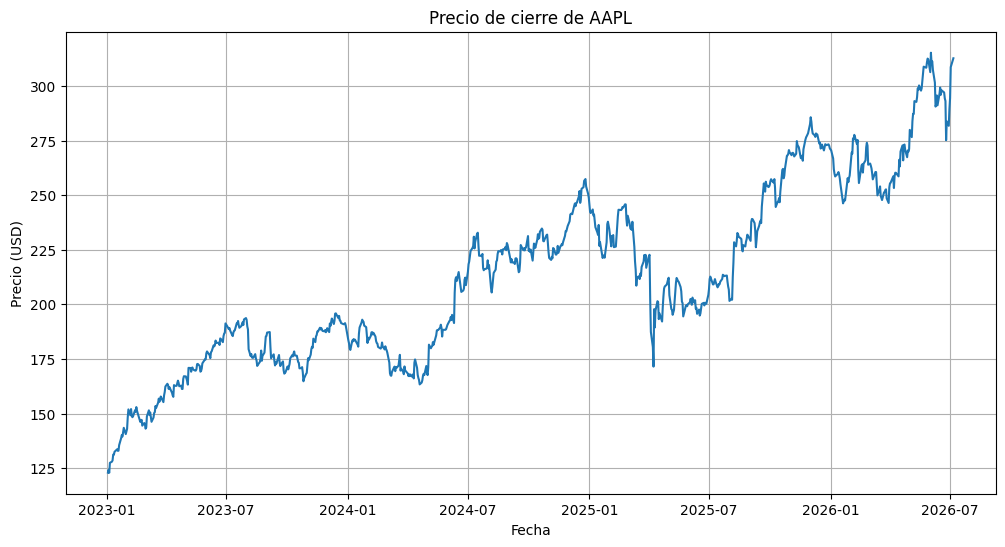

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title(f'Precio de cierre de {ticker}')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid(True)
plt.show()

In [ ]:
# Retorno diario = cuánto % subió o bajó el precio cada día
data['Retorno Diario'] = data['Close'].pct_change()

# Volatilidad = qué tan "movido" es el precio (desviación estándar de los retornos)
volatilidad = data['Retorno Diario'].std()

print(f"Volatilidad diaria de {ticker}: {volatilidad:.4%}")
print(f"Retorno promedio diario: {data['Retorno Diario'].mean():.4%}")

Volatilidad diaria de AAPL: 1.6219%
Retorno promedio diario: 0.1195%


In [ ]:
tickers = ["AAPL", "KO", "TSLA"]

resultados = []

for t in tickers:
    d = yf.download(t, start="2023-01-01", end="2026-07-07")
    precio_cierre = d['Close'].squeeze()  # <- esta línea es la corrección
    retorno_diario = precio_cierre.pct_change()

    vol_anual = retorno_diario.std() * (252 ** 0.5)
    retorno_anual = retorno_diario.mean() * 252

    resultados.append({
        "Ticker": t,
        "Retorno anualizado": f"{retorno_anual:.2%}",
        "Volatilidad anualizada": f"{vol_anual:.2%}"
    })

import pandas as pd
tabla = pd.DataFrame(resultados)
tabla

/tmp/ipykernel_1384/4225164965.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download(t, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1384/4225164965.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download(t, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1384/4225164965.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download(t, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


,Ticker,Retorno anualizado,Volatilidad anualizada
0,AAPL,30.11%,25.75%
1,KO,12.10%,15.47%
2,TSLA,55.64%,58.03%


In [ ]:
tickers = ["AAPL", "KO", "TSLA"]

resultados = []

for t in tickers:
    d = yf.download(t, start="2023-01-01", end="2026-07-07")
    precio_cierre = d['Close'].squeeze()
    retorno_diario = precio_cierre.pct_change()

    vol_anual = retorno_diario.std() * (252 ** 0.5)
    retorno_anual = retorno_diario.mean() * 252
    ratio = retorno_anual / vol_anual  # retorno por unidad de riesgo

    resultados.append({
        "Ticker": t,
        "Retorno anualizado": f"{retorno_anual:.2%}",
        "Volatilidad anualizada": f"{vol_anual:.2%}",
        "Ratio Retorno/Riesgo": f"{ratio:.2f}"
    })

import pandas as pd
tabla = pd.DataFrame(resultados)
tabla


/tmp/ipykernel_1384/3039010556.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download(t, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1384/3039010556.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download(t, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1384/3039010556.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download(t, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


,Ticker,Retorno anualizado,Volatilidad anualizada,Ratio Retorno/Riesgo
0,AAPL,30.11%,25.75%,1.17
1,KO,12.10%,15.47%,0.78
2,TSLA,55.64%,58.03%,0.96


/tmp/ipykernel_1384/4133418141.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download(t, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1384/4133418141.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download(t, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1384/4133418141.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download(t, start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


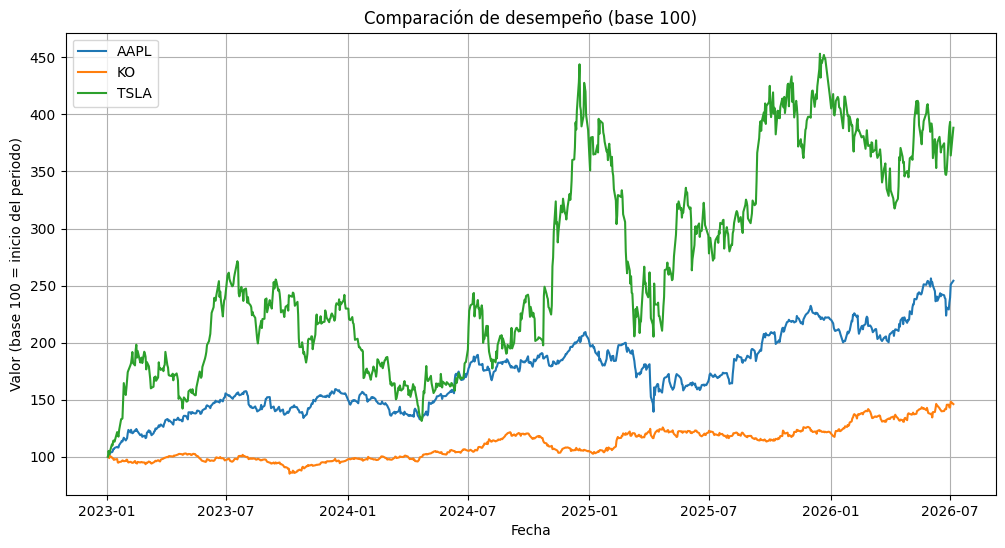

In [ ]:
plt.figure(figsize=(12,6))

for t in tickers:
    d = yf.download(t, start="2023-01-01", end="2026-07-07")
    precio_normalizado = d['Close'].squeeze() / d['Close'].squeeze().iloc[0] * 100
    plt.plot(precio_normalizado, label=t)

plt.title('Comparación de desempeño (base 100)')
plt.xlabel('Fecha')
plt.ylabel('Valor (base 100 = inicio del periodo)')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1384/3513659059.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


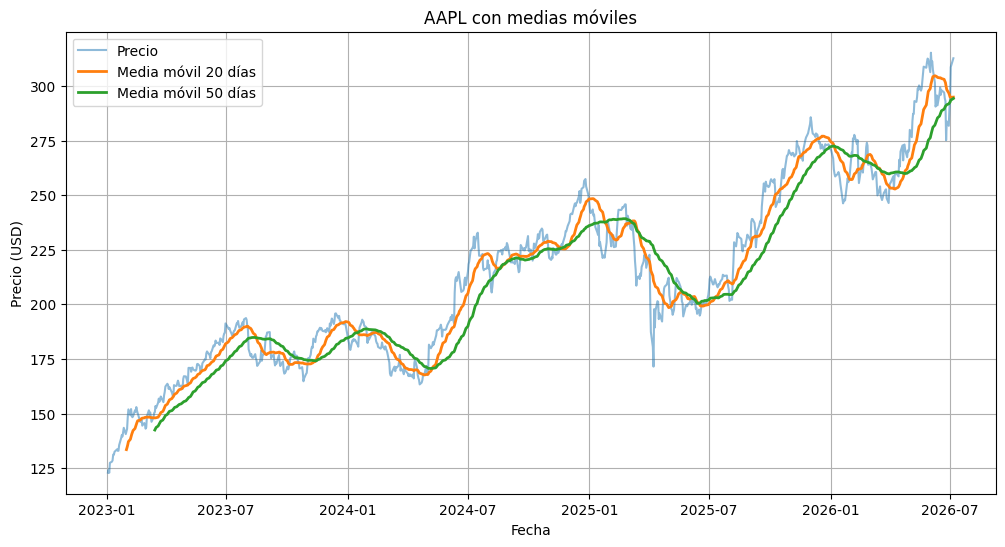

In [ ]:
d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

# Media móvil de 20 días (corto plazo) y 50 días (mediano plazo)
media_20 = precio.rolling(window=20).mean()
media_50 = precio.rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(precio, label='Precio', alpha=0.5)
plt.plot(media_20, label='Media móvil 20 días', linewidth=2)
plt.plot(media_50, label='Media móvil 50 días', linewidth=2)
plt.title('AAPL con medias móviles')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

media_20 = precio.rolling(window=20).mean()
media_50 = precio.rolling(window=50).mean()

# Creamos una señal: 1 si la media corta está arriba de la larga, -1 si está abajo
señal = (media_20 > media_50).astype(int)
señal = señal.replace(0, -1)

# Detectamos el momento EXACTO del cruce (cuando la señal cambia)
cruce = señal.diff()

# Golden Cross: cuando la señal pasa de -1 a 1 (cruce hacia arriba, diff = 2)
golden_cross = d.index[cruce == 2]

# Death Cross: cuando la señal pasa de 1 a -1 (cruce hacia abajo, diff = -2)
death_cross = d.index[cruce == -2]

print(f"Golden Crosses detectados: {len(golden_cross)}")
print(golden_cross)
print(f"\nDeath Crosses detectados: {len(death_cross)}")
print(death_cross)

/tmp/ipykernel_1384/3543611242.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed

Golden Crosses detectados: 10
DatetimeIndex(['2023-03-15', '2023-11-14', '2024-05-08', '2024-08-27',
               '2024-12-03', '2025-03-06', '2025-06-05', '2025-07-11',
               '2026-02-23', '2026-04-23'],
              dtype='datetime64[ns]', name='Date', freq=None)

Death Crosses detectados: 9
DatetimeIndex(['2023-08-16', '2024-01-17', '2024-08-20', '2024-11-19',
               '2025-01-27', '2025-03-17', '2025-06-17', '2026-01-07',
               '2026-03-18'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [ ]:
d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

media_20 = precio.rolling(window=20).mean()
media_50 = precio.rolling(window=50).mean()

# Creamos una señal: 1 si la media corta está arriba de la larga, -1 si está abajo
señal = (media_20 > media_50).astype(int)
señal = señal.replace(0, -1)

# Detectamos el momento EXACTO del cruce (cuando la señal cambia)
cruce = señal.diff()

# Golden Cross: cuando la señal pasa de -1 a 1 (cruce hacia arriba, diff = 2)
golden_cross = d.index[cruce == 2]

# Death Cross: cuando la señal pasa de 1 a -1 (cruce hacia abajo, diff = -2)
death_cross = d.index[cruce == -2]

print(f"Golden Crosses detectados: {len(golden_cross)}")
print(golden_cross)
print(f"\nDeath Crosses detectados: {len(death_cross)}")
print(death_cross)

/tmp/ipykernel_1384/3543611242.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed

Golden Crosses detectados: 10
DatetimeIndex(['2023-03-15', '2023-11-14', '2024-05-08', '2024-08-27',
               '2024-12-03', '2025-03-06', '2025-06-05', '2025-07-11',
               '2026-02-23', '2026-04-23'],
              dtype='datetime64[ns]', name='Date', freq=None)

Death Crosses detectados: 9
DatetimeIndex(['2023-08-16', '2024-01-17', '2024-08-20', '2024-11-19',
               '2025-01-27', '2025-03-17', '2025-06-17', '2026-01-07',
               '2026-03-18'],
              dtype='datetime64[ns]', name='Date', freq=None)


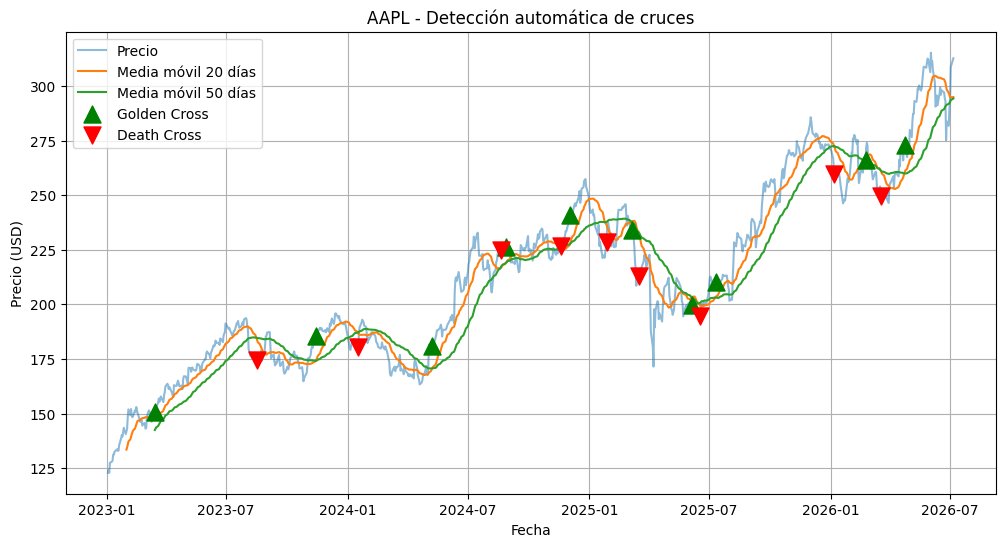

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(precio, label='Precio', alpha=0.5)
plt.plot(media_20, label='Media móvil 20 días', linewidth=1.5)
plt.plot(media_50, label='Media móvil 50 días', linewidth=1.5)

# Marcamos los Golden Cross en verde y Death Cross en rojo
plt.scatter(golden_cross, precio.loc[golden_cross], color='green', marker='^', s=150, label='Golden Cross', zorder=5)
plt.scatter(death_cross, precio.loc[death_cross], color='red', marker='v', s=150, label='Death Cross', zorder=5)

plt.title('AAPL - Detección automática de cruces')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1384/1000351603.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


Buy & Hold final: 254.23 (retorno total: 154.23%)
Estrategia (cruces) final: 156.66 (retorno total: 56.66%)


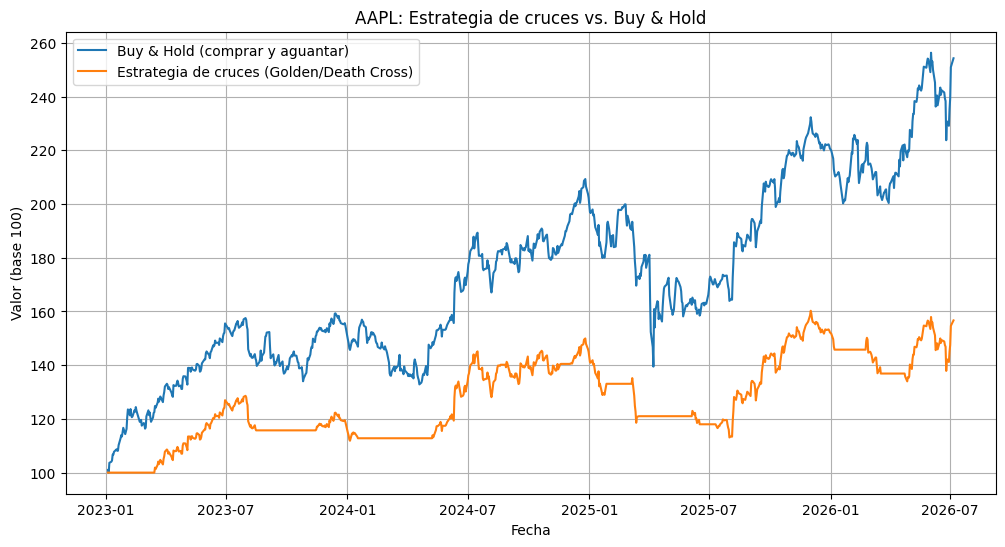

In [ ]:
d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

media_20 = precio.rolling(window=20).mean()
media_50 = precio.rolling(window=50).mean()

# Señal: 1 = estar comprado (media corta arriba), 0 = estar fuera del mercado
señal = (media_20 > media_50).astype(int)

# IMPORTANTE: usamos shift(1) porque la señal de HOY solo la conoces
# al CIERRE del día, así que recién puedes actuar mañana (evita "ver el futuro")
posicion = señal.shift(1)

# Retorno diario del precio
retorno_diario = precio.pct_change()

# Retorno de la estrategia: solo ganas/pierdes cuando estás "posicionado" (posicion=1)
retorno_estrategia = retorno_diario * posicion

# Retorno acumulado de cada enfoque (base 100)
buy_hold = (1 + retorno_diario).cumprod() * 100
estrategia = (1 + retorno_estrategia).cumprod() * 100

# Resultado final
print(f"Buy & Hold final: {buy_hold.iloc[-1]:.2f} (retorno total: {(buy_hold.iloc[-1]/100 - 1):.2%})")
print(f"Estrategia (cruces) final: {estrategia.iloc[-1]:.2f} (retorno total: {(estrategia.iloc[-1]/100 - 1):.2%})")

# Gráfico comparativo
plt.figure(figsize=(12,6))
plt.plot(buy_hold, label='Buy & Hold (comprar y aguantar)')
plt.plot(estrategia, label='Estrategia de cruces (Golden/Death Cross)')
plt.title('AAPL: Estrategia de cruces vs. Buy & Hold')
plt.xlabel('Fecha')
plt.ylabel('Valor (base 100)')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipykernel_1384/2102274855.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("TSLA", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


Buy & Hold final: 388.32 (retorno total: 288.32%)
Estrategia (cruces) final: 168.05 (retorno total: 68.05%)


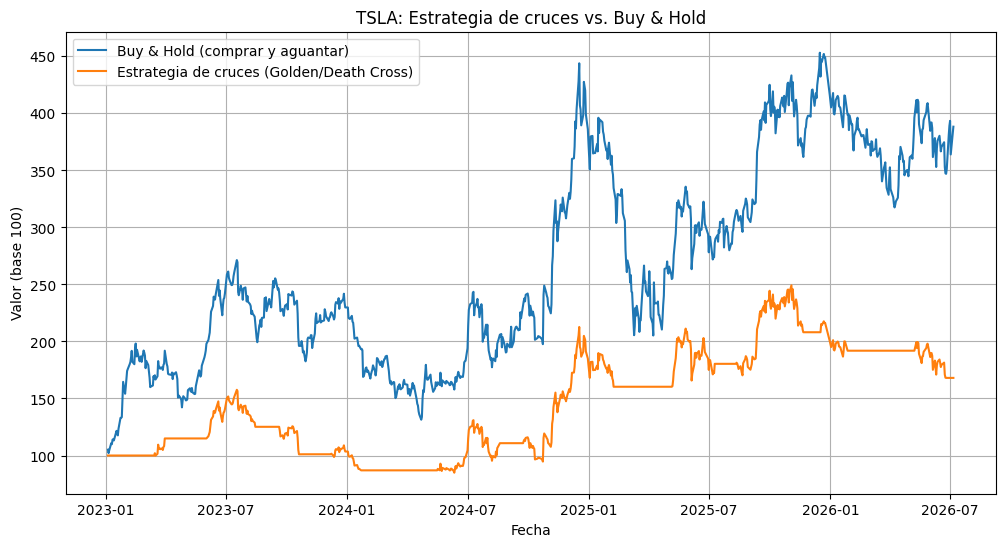

In [ ]:
d = yf.download("TSLA", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

media_20 = precio.rolling(window=20).mean()
media_50 = precio.rolling(window=50).mean()

señal = (media_20 > media_50).astype(int)
posicion = señal.shift(1)

retorno_diario = precio.pct_change()
retorno_estrategia = retorno_diario * posicion

buy_hold = (1 + retorno_diario).cumprod() * 100
estrategia = (1 + retorno_estrategia).cumprod() * 100

print(f"Buy & Hold final: {buy_hold.iloc[-1]:.2f} (retorno total: {(buy_hold.iloc[-1]/100 - 1):.2%})")
print(f"Estrategia (cruces) final: {estrategia.iloc[-1]:.2f} (retorno total: {(estrategia.iloc[-1]/100 - 1):.2%})")

plt.figure(figsize=(12,6))
plt.plot(buy_hold, label='Buy & Hold (comprar y aguantar)')
plt.plot(estrategia, label='Estrategia de cruces (Golden/Death Cross)')
plt.title('TSLA: Estrategia de cruces vs. Buy & Hold')
plt.xlabel('Fecha')
plt.ylabel('Valor (base 100)')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipykernel_1384/4186663112.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


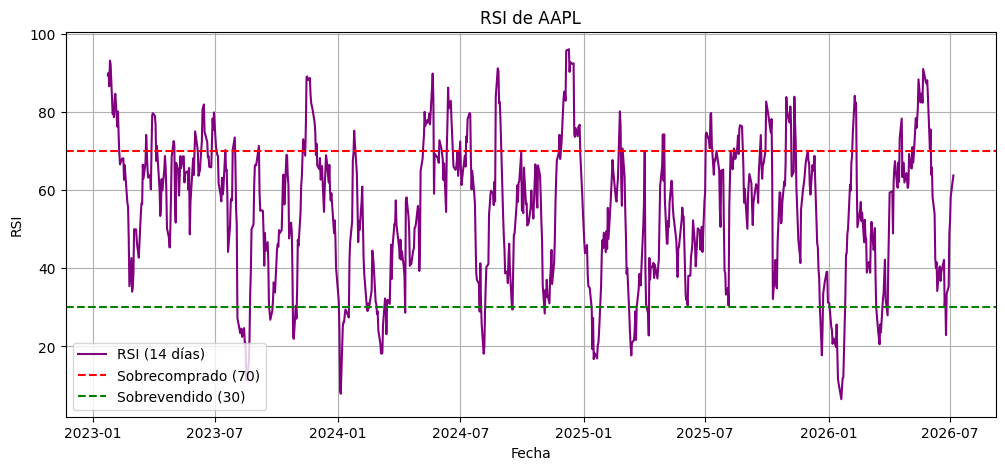

In [ ]:
d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

# Cálculo del RSI (14 días es el estándar de la industria)
delta = precio.diff()
ganancia = delta.where(delta > 0, 0)
perdida = -delta.where(delta < 0, 0)

ganancia_promedio = ganancia.rolling(window=14).mean()
perdida_promedio = perdida.rolling(window=14).mean()

rs = ganancia_promedio / perdida_promedio
rsi = 100 - (100 / (1 + rs))

# Gráfico del RSI
plt.figure(figsize=(12,5))
plt.plot(rsi, label='RSI (14 días)', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Sobrecomprado (70)')
plt.axhline(30, color='green', linestyle='--', label='Sobrevendido (30)')
plt.title('RSI de AAPL')
plt.xlabel('Fecha')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipykernel_1384/799983887.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


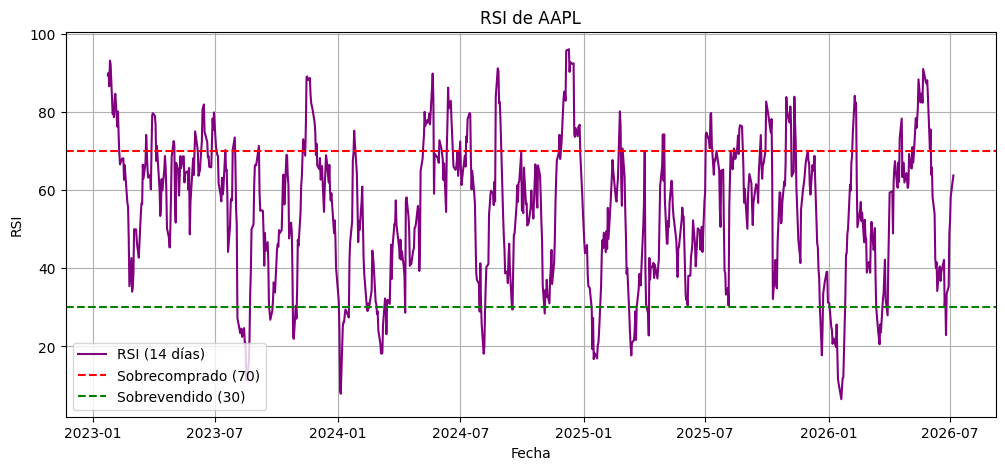

In [ ]:
d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

# Cálculo del RSI (14 días es el estándar de la industria)
delta = precio.diff()
ganancia = delta.where(delta > 0, 0)
perdida = -delta.where(delta < 0, 0)

ganancia_promedio = ganancia.rolling(window=14).mean()
perdida_promedio = perdida.rolling(window=14).mean()

rs = ganancia_promedio / perdida_promedio
rsi = 100 - (100 / (1 + rs))

# Gráfico del RSI
plt.figure(figsize=(12,5))
plt.plot(rsi, label='RSI (14 días)', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Sobrecomprado (70)')
plt.axhline(30, color='green', linestyle='--', label='Sobrevendido (30)')
plt.title('RSI de AAPL')
plt.xlabel('Fecha')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1384/971298639.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


Buy & Hold final: 254.23 (retorno total: 154.23%)
Estrategia RSI final: 252.35 (retorno total: 152.35%)


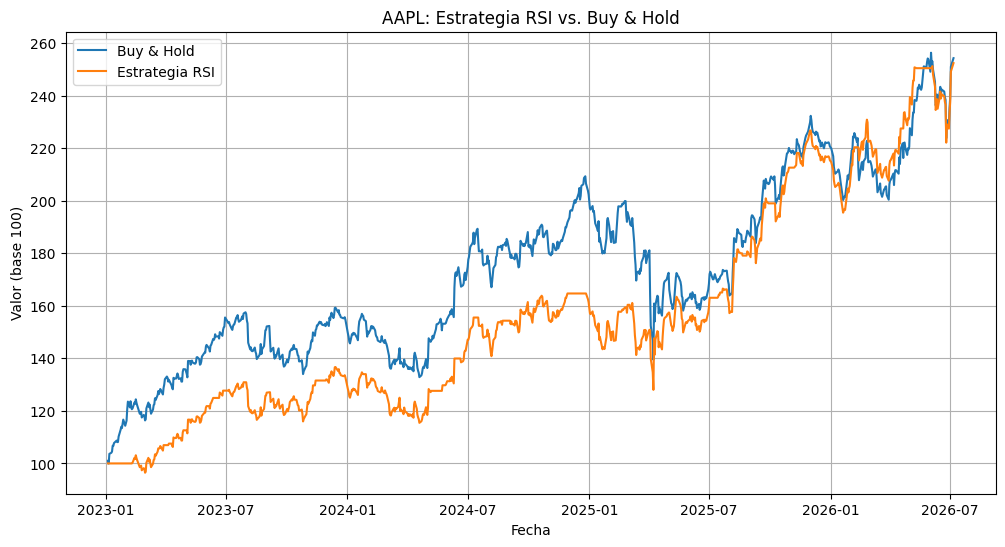

In [ ]:
d = yf.download("AAPL", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

# Recalculamos el RSI
delta = precio.diff()
ganancia = delta.where(delta > 0, 0)
perdida = -delta.where(delta < 0, 0)
ganancia_promedio = ganancia.rolling(window=14).mean()
perdida_promedio = perdida.rolling(window=14).mean()
rs = ganancia_promedio / perdida_promedio
rsi = 100 - (100 / (1 + rs))

# Estrategia: comprado mientras RSI < 70, fuera del mercado si RSI >= 70
# (una versión simple: "no comprar/estar en sobrecompra")
señal = (rsi < 70).astype(int)
posicion = señal.shift(1)  # evitamos look-ahead bias, igual que antes

retorno_diario = precio.pct_change()
retorno_estrategia = retorno_diario * posicion

buy_hold = (1 + retorno_diario).cumprod() * 100
estrategia_rsi = (1 + retorno_estrategia).cumprod() * 100

print(f"Buy & Hold final: {buy_hold.iloc[-1]:.2f} (retorno total: {(buy_hold.iloc[-1]/100 - 1):.2%})")
print(f"Estrategia RSI final: {estrategia_rsi.iloc[-1]:.2f} (retorno total: {(estrategia_rsi.iloc[-1]/100 - 1):.2%})")

plt.figure(figsize=(12,6))
plt.plot(buy_hold, label='Buy & Hold')
plt.plot(estrategia_rsi, label='Estrategia RSI')
plt.title('AAPL: Estrategia RSI vs. Buy & Hold')
plt.xlabel('Fecha')
plt.ylabel('Valor (base 100)')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_1384/730874037.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("TSLA", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed


Buy & Hold final: 388.32 (retorno total: 288.32%)
Estrategia RSI final: 126.02 (retorno total: 26.02%)


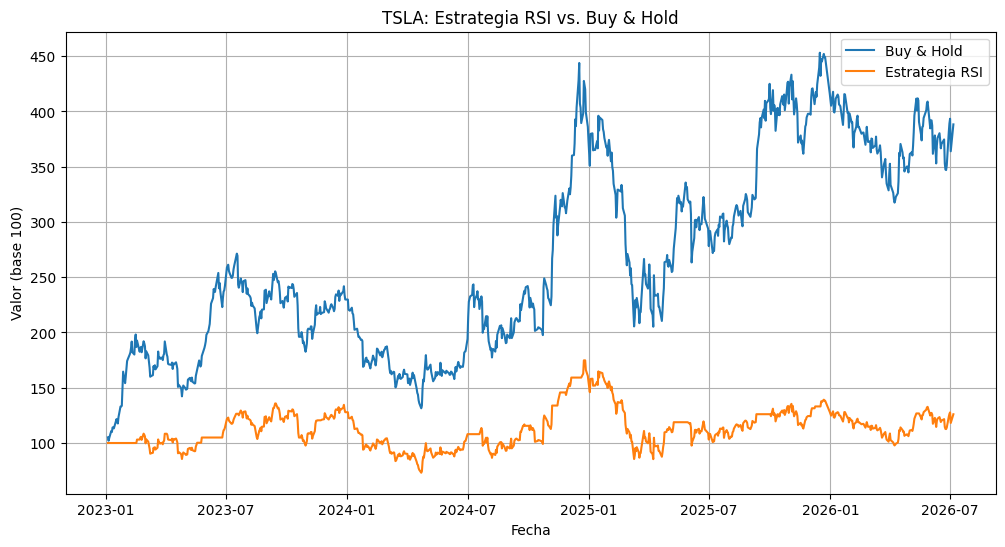

In [ ]:
d = yf.download("TSLA", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

delta = precio.diff()
ganancia = delta.where(delta > 0, 0)
perdida = -delta.where(delta < 0, 0)
ganancia_promedio = ganancia.rolling(window=14).mean()
perdida_promedio = perdida.rolling(window=14).mean()
rs = ganancia_promedio / perdida_promedio
rsi = 100 - (100 / (1 + rs))

señal = (rsi < 70).astype(int)
posicion = señal.shift(1)

retorno_diario = precio.pct_change()
retorno_estrategia = retorno_diario * posicion

buy_hold = (1 + retorno_diario).cumprod() * 100
estrategia_rsi = (1 + retorno_estrategia).cumprod() * 100

print(f"Buy & Hold final: {buy_hold.iloc[-1]:.2f} (retorno total: {(buy_hold.iloc[-1]/100 - 1):.2%})")
print(f"Estrategia RSI final: {estrategia_rsi.iloc[-1]:.2f} (retorno total: {(estrategia_rsi.iloc[-1]/100 - 1):.2%})")

plt.figure(figsize=(12,6))
plt.plot(buy_hold, label='Buy & Hold')
plt.plot(estrategia_rsi, label='Estrategia RSI')
plt.title('TSLA: Estrategia RSI vs. Buy & Hold')
plt.xlabel('Fecha')
plt.ylabel('Valor (base 100)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
d = yf.download("TSLA", start="2023-01-01", end="2026-07-07")
precio = d['Close'].squeeze()

delta = precio.diff()
ganancia = delta.where(delta > 0, 0)
perdida = -delta.where(delta < 0, 0)
ganancia_promedio = ganancia.rolling(window=14).mean()
perdida_promedio = perdida.rolling(window=14).mean()
rs = ganancia_promedio / perdida_promedio
rsi = 100 - (100 / (1 + rs))

señal = (rsi < 70).astype(int)
posicion = señal.shift(1)

retorno_diario = precio.pct_change()
retorno_estrategia = retorno_diario * posicion

buy_hold = (1 + retorno_diario).cumprod() * 100
estrategia_rsi = (1 + retorno_estrategia).cumprod() * 100

print(f"Buy & Hold final: {buy_hold.iloc[-1]:.2f} (retorno total: {(buy_hold.iloc[-1]/100 - 1):.2%})")
print(f"Estrategia RSI final: {estrategia_rsi.iloc[-1]:.2f} (retorno total: {(estrategia_rsi.iloc[-1]/100 - 1):.2%})")

/tmp/ipykernel_1384/3907829224.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download("TSLA", start="2023-01-01", end="2026-07-07")
[*********************100%***********************]  1 of 1 completed

Buy & Hold final: 388.32 (retorno total: 288.32%)
Estrategia RSI final: 126.02 (retorno total: 26.02%)
